In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from scipy.stats import mannwhitneyu
import matplotlib.patches as mpl_patches

In [2]:
df=pd.read_table('Fig5c.txt')
df.head()

,Seq_ID,Sample_ID,Mg,T76fs
0,22615,S1-100,2624.01,ref
1,22628,S10-100,3146.22,ref
2,2876_AM,S10-101,3038.21,ref
3,22637,S10-102,3065.45,ref
4,27158,S10-12,2601.31,ref


## Remove missing data, Col-0 and Cvi-0

In [3]:
df=df.loc[(df['T76fs'] != '.') & (df['Sample_ID'] != 'Col-0') & (df['Sample_ID'] != 'Cvi-0')]
df.head()

,Seq_ID,Sample_ID,Mg,T76fs
0,22615,S1-100,2624.01,ref
1,22628,S10-100,3146.22,ref
2,2876_AM,S10-101,3038.21,ref
3,22637,S10-102,3065.45,ref
4,27158,S10-12,2601.31,ref


Text(0, 0.5, 'Leaf [Mg] \n(µg.g$^{-1}$ DW)')

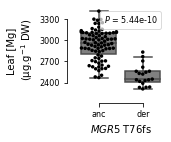

In [4]:
alt=df[df['T76fs'] == 'ref']
ref=df[df['T76fs'] == 'alt']



@ticker.FuncFormatter
def major_formatter(x, pos):
    y = x /1000000
    return "%.0f" % y
cm = 1/2.54
plt.figure(figsize=(4*cm,4*cm))
ax=sns.boxplot(x='T76fs', 
            y='Mg',
            color='grey',
            data=df,
            fliersize=0,
            linewidth=1.5)
ax=sns.swarmplot(x='T76fs', 
            y='Mg',
            color='0',
            data=df,
            s=2,
            linewidth=1.5)

r,p = mannwhitneyu(alt['Mg'],ref['Mg'])
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 2
labels=[]
labels.append(r"$P$ = {:.2e}".format(p))
plt.legend(handles, labels, loc='best', fontsize=8, 
      fancybox=True, framealpha=0.7, 
      handlelength=0, handletextpad=0)


ax.yaxis.set_major_locator(ticker.MultipleLocator(300))
sns.despine(trim=True,offset=10)
ax.set_xticklabels(['anc', 'der'])
plt.tick_params(labelsize=8)
plt.xlabel('$\itMGR5$ T76fs',fontsize=10)
plt.ylabel('Leaf [Mg] \n(µg.g$^{-1}$ DW)',fontsize=10)
# plt.savefig("Fig5c.pdf", format="pdf",bbox_inches="tight")